In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Define the directory containing the Parquet files
data_dir = os.path.join('data', 'iam_dataset')

# Read each Parquet file into a separate DataFrame
account_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'account_entitlements.parquet'))
accounts_df = pd.read_parquet(os.path.join(data_dir, 'accounts.parquet'))
applications_df = pd.read_parquet(os.path.join(data_dir, 'applications.parquet'))
entitlement_group_assignments_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_assignments.parquet'))
entitlement_group_relations_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_relations.parquet'))
entitlement_groups_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_groups.parquet'))
entitlements_df = pd.read_parquet(os.path.join(data_dir, 'entitlements.parquet'))
identities_df = pd.read_parquet(os.path.join(data_dir, 'identities.parquet'))
resources_df = pd.read_parquet(os.path.join(data_dir, 'resources.parquet'))

# Print the shapes of the DataFrames
print(f"Shape of account_entitlements_df: {account_entitlements_df.shape}")
print(f"Shape of accounts_df: {accounts_df.shape}")
print(f"Shape of applications_df: {applications_df.shape}")
print(f"Shape of entitlement_group_assignments_df: {entitlement_group_assignments_df.shape}")
print(f"Shape of entitlement_group_relations_df: {entitlement_group_relations_df.shape}")
print(f"Shape of entitlement_groups_df: {entitlement_groups_df.shape}")
print(f"Shape of entitlements_df: {entitlements_df.shape}")
print(f"Shape of identities_df: {identities_df.shape}")
print(f"Shape of resources_df: {resources_df.shape}")

Shape of account_entitlements_df: (887838, 5)
Shape of accounts_df: (292873, 6)
Shape of applications_df: (1000, 4)
Shape of entitlement_group_assignments_df: (199373, 3)
Shape of entitlement_group_relations_df: (99, 2)
Shape of entitlement_groups_df: (500, 4)
Shape of entitlements_df: (10000, 5)
Shape of identities_df: (50000, 8)
Shape of resources_df: (1981, 4)


In [3]:
# Group by 'identity_id' and count the number of accounts for each user
accounts_per_user = accounts_df.groupby('identity_id').size()

# Get the distribution of the number of accounts
account_distribution = accounts_per_user.value_counts()

print("Distribution of accounts per user:")
print(account_distribution)

Distribution of accounts per user:
8     11870
6     10009
7      7856
4      7799
3      6759
5      5100
9       298
10      187
11      122
Name: count, dtype: int64


Distribution of entitlements per account:
2    109895
3     78079
4     59180
5     37838
1      7877
6         4
Name: count, dtype: int64


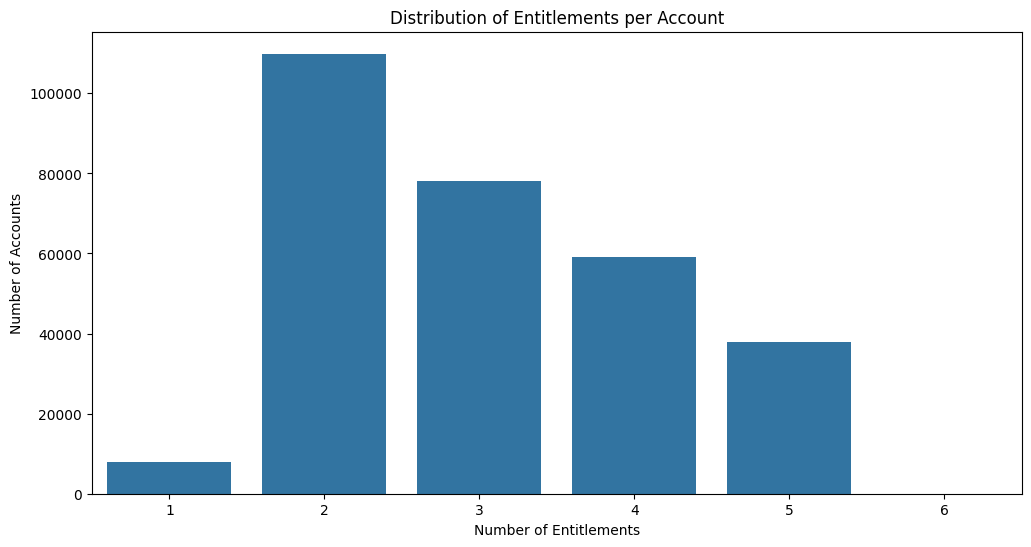

In [4]:


# --- Analysis for account_entitlements ---

# Group by 'account_id' and count the number of entitlements for each account
entitlements_per_account = account_entitlements_df.groupby('account_id').size()

# Get the distribution of the number of entitlements
entitlement_distribution = entitlements_per_account.value_counts()

print("Distribution of entitlements per account:")
print(entitlement_distribution)

# Create a bar plot of the entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_distribution.index, y=entitlement_distribution.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Entitlements per Account")
plt.show()





Distribution of entitlement groups per identity:
4     11414
3     11204
5      8276
2      7474
6      4856
7      2609
1      2542
8      1023
9       428
10      127
11       38
12        6
13        2
14        1
Name: count, dtype: int64


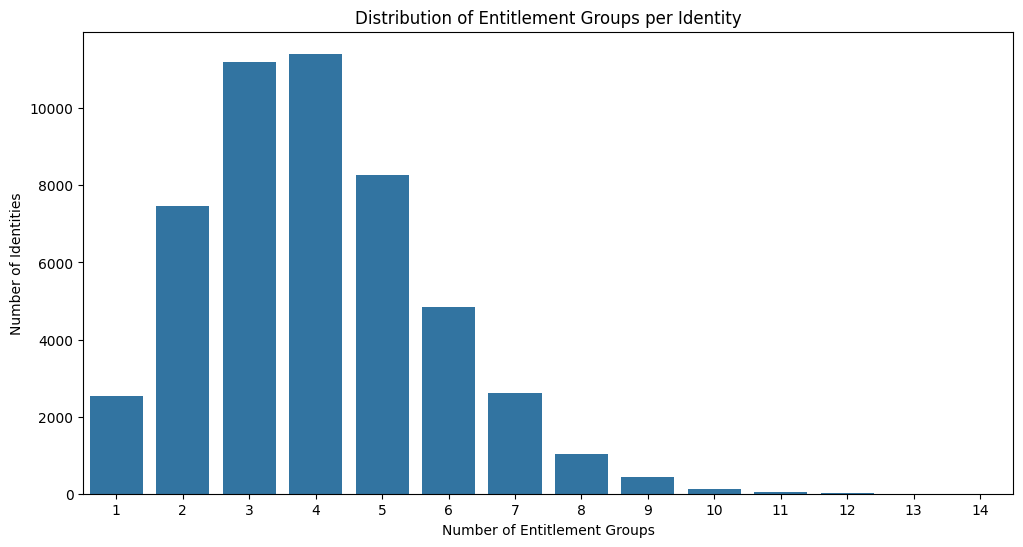

In [5]:
# --- Analysis for entitlement_group_assignments ---

# Group by 'identity_id' and count the number of entitlement groups for each identity
entitlement_groups_per_identity = entitlement_group_assignments_df.groupby('identity_id').size()

# Get the distribution of the number of entitlement groups
entitlement_group_distribution = entitlement_groups_per_identity.value_counts()

print("\nDistribution of entitlement groups per identity:")
print(entitlement_group_distribution)

# Create a bar plot of the entitlement group distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_group_distribution.index, y=entitlement_group_distribution.values)
plt.xlabel("Number of Entitlement Groups")
plt.ylabel("Number of Identities")
plt.title("Distribution of Entitlement Groups per Identity")
plt.show()

In [6]:
print("applications_df columns:", applications_df.columns)
print("resources_df columns:", resources_df.columns)
print("entitlements_df columns:", entitlements_df.columns)
print("account_entitlements_df columns:", account_entitlements_df.columns)
print("accounts_df columns:", accounts_df.columns)

applications_df columns: Index(['app_id', 'app_name', 'business_criticality', 'app_owner_id'], dtype='str')
resources_df columns: Index(['resource_id', 'app_id', 'iga_source_name', 'connection_type'], dtype='str')
entitlements_df columns: Index(['entitlement_id', 'resource_id', 'entitlement_name', 'is_requestable',
       'risk_level'],
      dtype='str')
account_entitlements_df columns: Index(['identity_id', 'account_id', 'entitlement_id', 'grant_date',
       'assignment_type'],
      dtype='str')
accounts_df columns: Index(['identity_id', 'resource_id', 'account_id', 'account_name',
       'is_privileged', 'status'],
      dtype='str')
